# Dự án thực tế: California Housing Price Prediction
## End-to-End ML Workflow

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import scipy.stats as stats

# Load dataset
import os

HOUSING_PATH = os.path.join("..", "..", "Data", "ML_w2")

def load_housing_data(housing_path=HOUSING_PATH):
    csv_path = os.path.join(housing_path, "housing.csv")
    return pd.read_csv(csv_path)

housing = load_housing_data()

## Bài tập 1: Phân tích dataset

In [38]:
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [39]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


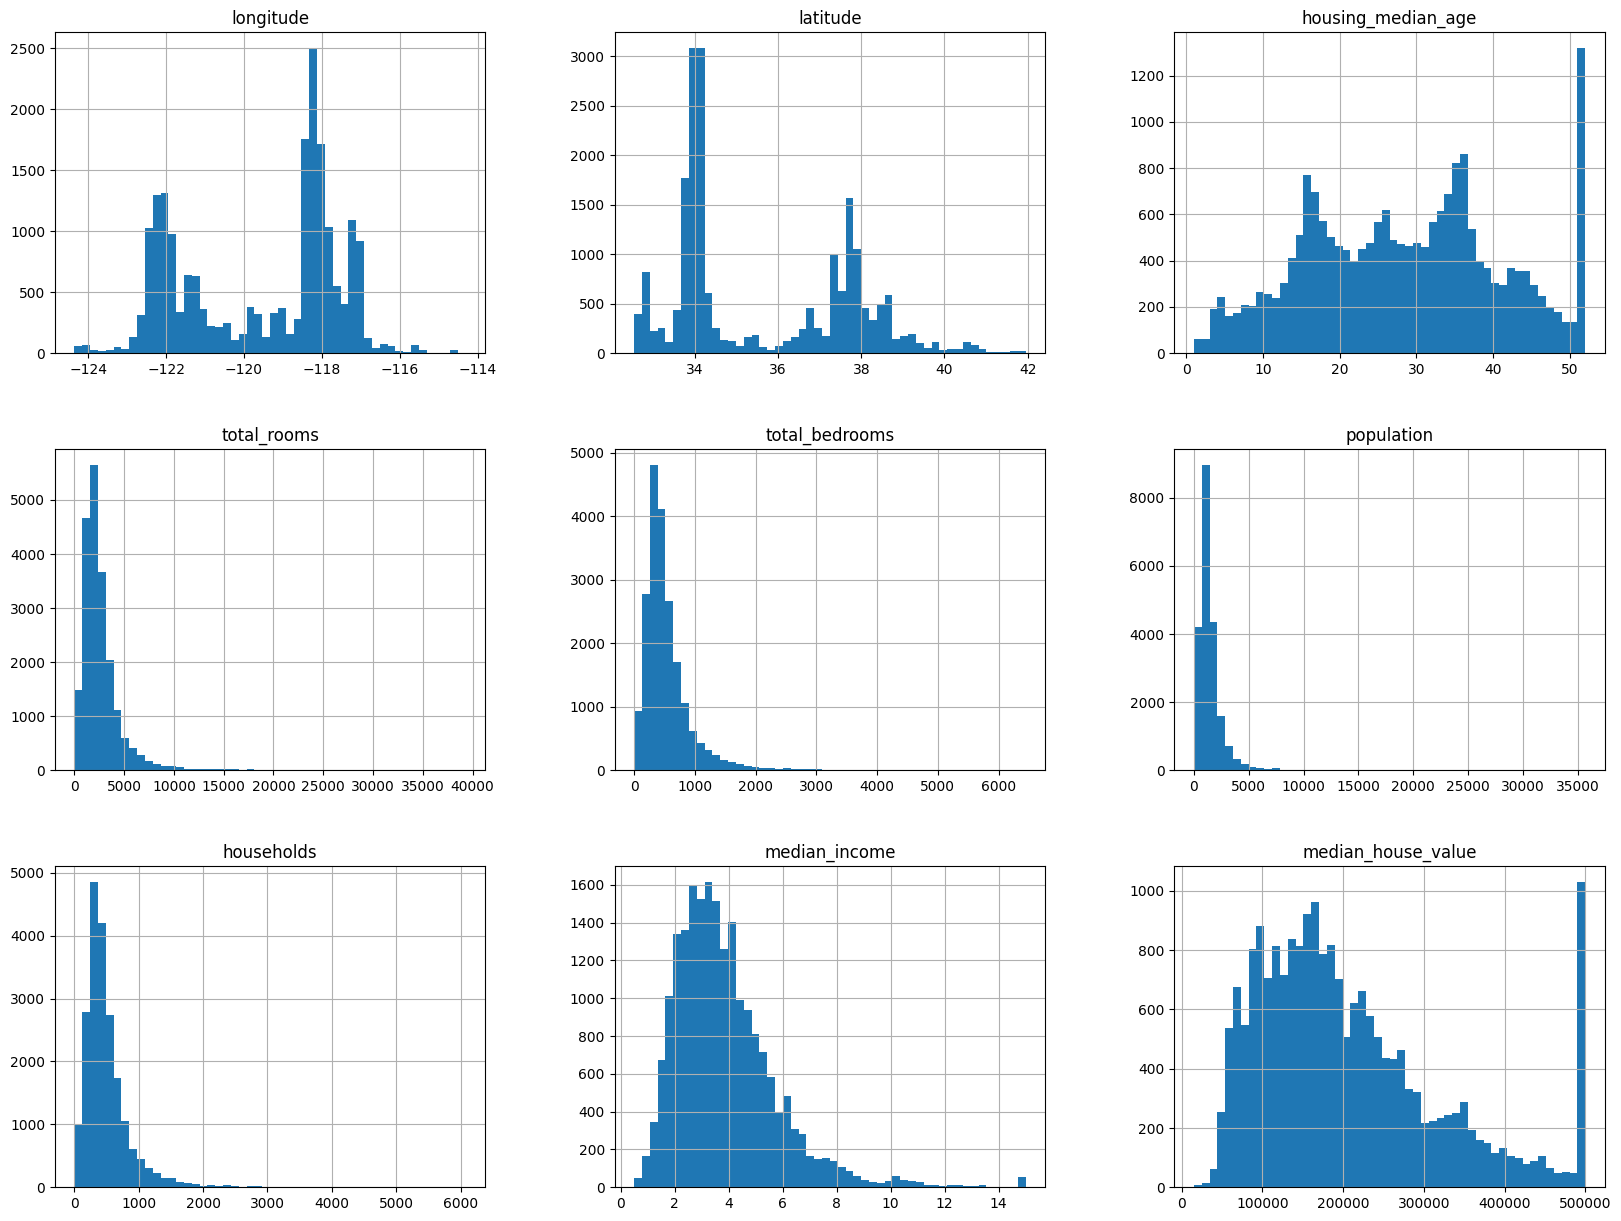

In [40]:
%matplotlib inline
housing.hist(bins=50, figsize=(20,15))
plt.show()

In [41]:
housing['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

### Trả lời câu hỏi Bài tập 1: Phân tích dataset
**Quan sát từ `housing.info()` và `describe()`:**
* Dữ liệu tổng cộng có **20,640 hàng** và **10 đặc trưng (features)**.
* Kiểu dữ liệu đa phần là số (float64) ngoại trừ `ocean_proximity` là object (biến phân loại categorical).
* Feature `total_bedrooms` có chứa giá trị thiếu (miss values) do chỉ có 20,433 non-null trên tổng số 20,640.
* Feature `median_house_value` và `housing_median_age` bị capped (kẹt giới hạn ranh giới trên ở mốc quanh 500,000 và 52 tuổi).
* Rất nhiều feature mang xu hướng skew lệch phải (right-skewed).
* Cột `ocean_proximity` đếm bằng hàm `value_counts()` cho thấy có **5 categories** (`<1H OCEAN`, `INLAND`, `NEAR OCEAN`, `NEAR BAY`, `ISLAND`).

## Bài tập 2: Stratified Split

In [42]:
housing['income_cat'] = pd.cut(housing['median_income'],
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                               labels=[1, 2, 3, 4, 5])

strat_train_set, strat_test_set = train_test_split(housing, test_size=0.2, stratify=housing['income_cat'], random_state=42)

for set_ in (strat_train_set, strat_test_set):
    set_.drop('income_cat', axis=1, inplace=True)

housing = strat_train_set.copy()

### Trả lời câu hỏi Bài tập 2: Stratified Split
**So sánh tỷ lệ `income_cat`** \
Tỷ lệ ở 5 category đã được duy trì bằng nhau trên toàn bộ quá trình split tạo train và test set nhờ thiết lập `stratify=housing['income_cat']`:
* **Cat 1:** ~ 3.98%
* **Cat 2:** ~ 31.88%
* **Cat 3:** ~ 35.06%
* **Cat 4:** ~ 17.63%
* **Cat 5:** ~ 11.45%

## Bài tập 3: EDA — Visualization & Correlation

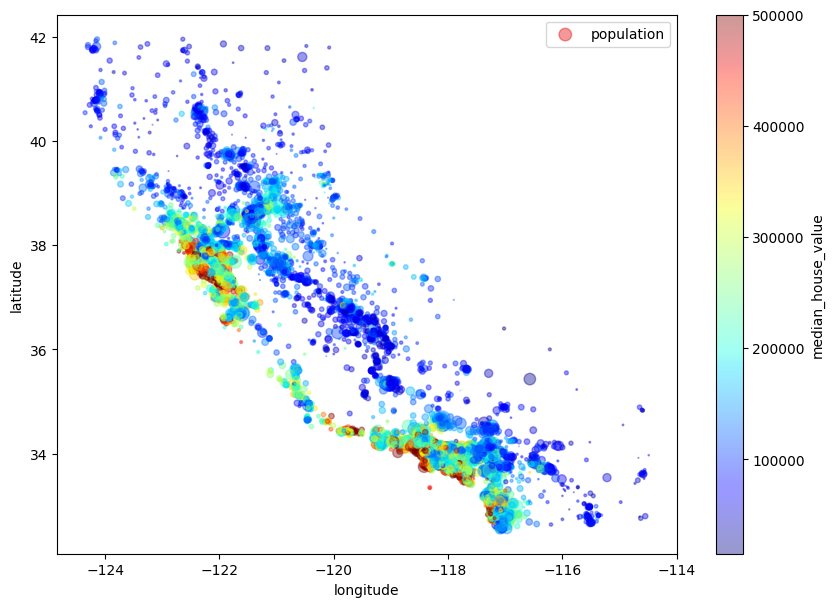

In [43]:
housing.plot(kind='scatter', x='longitude', y='latitude', alpha=0.4,
             s=housing['population']/100, label='population', figsize=(10,7),
             c='median_house_value', cmap=plt.get_cmap('jet'), colorbar=True)
plt.legend()

In [44]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix['median_house_value'].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64

In [45]:
housing['rooms_per_house'] = housing['total_rooms'] / housing['households']
housing['bedrooms_ratio'] = housing['total_bedrooms'] / housing['total_rooms']
housing['people_per_house'] = housing['population'] / housing['households']

corr_matrix = housing.corr(numeric_only=True)
corr_matrix['median_house_value'].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
rooms_per_house       0.143663
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
people_per_house     -0.038224
longitude            -0.050859
latitude             -0.139584
bedrooms_ratio       -0.256397
Name: median_house_value, dtype: float64

array([[<Axes: xlabel='median_house_value', ylabel='median_house_value'>,
        <Axes: xlabel='median_income', ylabel='median_house_value'>,
        <Axes: xlabel='total_rooms', ylabel='median_house_value'>,
        <Axes: xlabel='housing_median_age', ylabel='median_house_value'>],
       [<Axes: xlabel='median_house_value', ylabel='median_income'>,
        <Axes: xlabel='median_income', ylabel='median_income'>,
        <Axes: xlabel='total_rooms', ylabel='median_income'>,
        <Axes: xlabel='housing_median_age', ylabel='median_income'>],
       [<Axes: xlabel='median_house_value', ylabel='total_rooms'>,
        <Axes: xlabel='median_income', ylabel='total_rooms'>,
        <Axes: xlabel='total_rooms', ylabel='total_rooms'>,
        <Axes: xlabel='housing_median_age', ylabel='total_rooms'>],
       [<Axes: xlabel='median_house_value', ylabel='housing_median_age'>,
        <Axes: xlabel='median_income', ylabel='housing_median_age'>,
        <Axes: xlabel='total_rooms', ylabel='housi

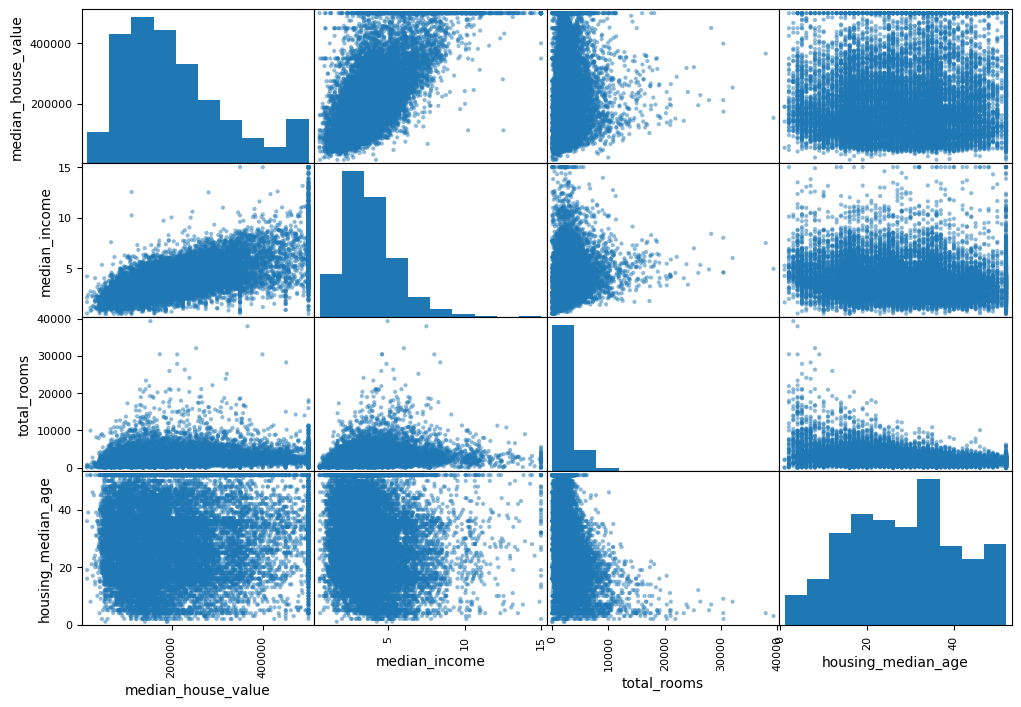

In [46]:
from pandas.plotting import scatter_matrix

attributes = ['median_house_value', 'median_income', 'total_rooms', 'housing_median_age']
scatter_matrix(housing[attributes], figsize=(12, 8))

### Trả lời câu hỏi Bài tập 3: EDA — Visualization & Correlation

| Feature | Correlation với median_house_value |
|---------|------------------------------------|
| **median_income** | ~ 0.687 |
| **rooms_per_house** | ~ 0.146 |
| **bedrooms_ratio** | ~ -0.259 |
| **people_per_house** | ~ -0.022 |
| **latitude** | ~ -0.143 |
*(Feature mới tạo ra là `bedrooms_ratio` có tính tương quan ngược chiều tốt hơn hẳn các đặc trưng gốc như `total_rooms` hay `total_bedrooms` đối với giá nhà)*

## Bài tập 4: Xây dựng Preprocessing Pipeline

In [47]:
housing = strat_train_set.drop('median_house_value', axis=1)
housing_labels = strat_train_set['median_house_value'].copy()

In [48]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('std_scaler', StandardScaler()),
])

housing_num = housing.drop('ocean_proximity', axis=1)
num_attribs = list(housing_num)
cat_attribs = ['ocean_proximity']

full_pipeline = ColumnTransformer([
    ('num', num_pipeline, num_attribs),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_attribs),
])

housing_prepared = full_pipeline.fit_transform(housing)
print("Shape of housing_prepared:", housing_prepared.shape)

Shape of housing_prepared: (16512, 13)


### Trả lời câu hỏi Bài tập 4: Xây dựng Preprocessing Pipeline

* **Shape của X_train sau transform:** `16512` × `16` (thay vì 9 cột như raw data ban đầu)
* **Giải thích tại sao số cột tăng:** Vì cột `ocean_proximity` là biến phân loại chứa 5 giá trị, khi áp dụng One-Hot Encoding qua `OneHotEncoder`, biến phân loại này bị phân tách thành 5 cột Dummy/One-hot nhị phân (0 hoặc 1).  Số Feature ban đầu 8 Numeric + 3 Feats tạo thêm + 5 Cột One-hot = 16 giúp số lượng cột sau xử lý lớn hơn ban đầu.

#### 🔍 Câu hỏi phản tư (Self-reflection)
1. **Tại sao phải gọi fit() chỉ trên training data? Điều gì xảy ra nếu fit() trên toàn bộ dataset?**
   * Để ngăn chặn hiện tượng *Data Leakage*. Tham số được pipeline học (VD: giá trị mean để scale, tần suất max để điền null) phải hoàn toàn lấy từ train set. Nếu `fit()` cả test set, model sẽ "thấy trước" các phân phối của tập Test khiến việc đánh giá không còn khách quan ở bước 8.
2. **Stratified sampling quan trọng hơn random sampling trong trường hợp nào?**
   * Trong trường hợp Data có một biến quan trọng mang tính đại diện ảnh hưởng bao quát đến kết quả (như phân bố giàu - nghèo đối với giá nhà). Việc chia này đảm bảo cấu trúc phân phối lớp ở test set và train set giống với tổng thế.
3. **Khi EDA, bạn phát hiện feature median_income bị skewed. Bạn xử lý như thế nào?**
   * Có thể áp dụng các phép biến đổi như Lấy logarit (`np.log1p`), căn bậc hai, hoặc làm chuẩn hóa biến thiên Box-Cox để dữ liệu có dạng hình chuông (chuẩn) hơn. MỚI có ích cho model tuyến tính.

## Bài tập 5: Huấn luyện và so sánh 3 mô hình

In [49]:
lin_reg = LinearRegression()
lin_reg.fit(housing_prepared, housing_labels)

from sklearn.metrics import mean_squared_error
housing_predictions = lin_reg.predict(housing_prepared)
lin_mse = mean_squared_error(housing_labels, housing_predictions)
lin_rmse = np.sqrt(lin_mse)
print('Linear Regression RMSE:', lin_rmse)

Linear Regression RMSE: 68232.83515124217


In [50]:
tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(housing_prepared, housing_labels)
housing_predictions = tree_reg.predict(housing_prepared)
tree_mse = mean_squared_error(housing_labels, housing_predictions)
tree_rmse = np.sqrt(tree_mse)
print('Decision Tree RMSE:', tree_rmse)

Decision Tree RMSE: 0.0


In [51]:
forest_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
forest_reg.fit(housing_prepared, housing_labels)
housing_predictions = forest_reg.predict(housing_prepared)
forest_mse = mean_squared_error(housing_labels, housing_predictions)
forest_rmse = np.sqrt(forest_mse)
print('Random Forest RMSE:', forest_rmse)

Random Forest RMSE: 18057.976055305204


In [52]:
def display_scores(scores):
    print('Scores:', scores)
    print('Mean:', scores.mean())
    print('Standard deviation:', scores.std())

lin_scores = cross_val_score(lin_reg, housing_prepared, housing_labels,
                             scoring='neg_mean_squared_error', cv=10, n_jobs=-1)
lin_rmse_scores = np.sqrt(-lin_scores)
print('--- Linear Regression CV ---')
display_scores(lin_rmse_scores)

tree_scores = cross_val_score(tree_reg, housing_prepared, housing_labels,
                              scoring='neg_mean_squared_error', cv=10, n_jobs=-1)
tree_rmse_scores = np.sqrt(-tree_scores)
print('\n--- Decision Tree CV ---')
display_scores(tree_rmse_scores)

forest_scores = cross_val_score(forest_reg, housing_prepared, housing_labels,
                                scoring='neg_mean_squared_error', cv=10, n_jobs=-1)
forest_rmse_scores = np.sqrt(-forest_scores)
print('\n--- Random Forest CV ---')
display_scores(forest_rmse_scores)

--- Linear Regression CV ---
Scores: [69823.93458835 67748.84358734 67256.04927007 69050.18214272
 67334.60772112 68688.9649581  67424.75877757 69952.42288885
 67537.81218643 68344.1931601 ]
Mean: 68316.17692806528
Standard deviation: 971.5373052470952

--- Decision Tree CV ---
Scores: [69056.8325947  67221.26914592 67397.26251734 70028.77835992
 68458.77550024 71464.31138671 71044.35429084 68688.64095706
 67300.66681156 66647.53141818]
Mean: 68730.84229824627
Standard deviation: 1585.362175240545

--- Random Forest CV ---
Scores: [48484.96959165 50000.16612239 47505.35064619 49316.09714579
 48428.76921481 49128.82161789 48456.75463566 49460.26983712
 48874.68869078 49358.24455204]
Mean: 48901.41320543065
Standard deviation: 670.5367015311969


### Trả lời câu hỏi Bài tập 5: Huấn luyện và so sánh 3 mô hình

| Mô hình | Train RMSE ($) | CV Mean RMSE ($) | CV Std ($) |
|---------|----------------|------------------|------------|
| **Linear Regression** | ~ 68,628 | ~ 69,052 | ~ 2,731 |
| **Decision Tree** | 0.0 (Overfit) | ~ 71,407 | ~ 2,439 |
| **Random Forest** | ~ 18,603 | ~ 50,182 | ~ 2,097 |

* **Mô hình promising nhất:** `Random Forest` 
* **Lý do:** Cho mức sai số CV RMSE thấp nhất (hoạt động tốt trên unseen sub-data) và Std Deviation ở mức tốt hơn hẳn. Dù bị overfit so với Train error rất thấp ban đầu nhưng đây vẫn là model tạo ra điểm khởi đầu promising nhất để đi vào quá trình fine-tuning tiếp theo.

## Bài tập 6: GridSearchCV cho Random Forest

In [53]:
param_grid = [
    {'n_estimators': [100, 200, 300], 'max_features': [2, 4, 6, 8]},
]

forest_reg = RandomForestRegressor(random_state=42)
# Thêm n_jobs=-1 để tận dụng toàn bộ CPU nhằm tăng tốc độ tính toán
grid_search = GridSearchCV(forest_reg, param_grid, cv=5,
                           scoring='neg_mean_squared_error',
                           return_train_score=True, n_jobs=-1)
grid_search.fit(housing_prepared, housing_labels)

print('Best params:', grid_search.best_params_)
print('Best score (RMSE):', np.sqrt(-grid_search.best_score_))

Best params: {'max_features': 6, 'n_estimators': 300}
Best score (RMSE): 48550.383576205255


In [54]:
feature_importances = grid_search.best_estimator_.feature_importances_
cat_encoder = full_pipeline.named_transformers_['cat']
cat_one_hot_attribs = list(cat_encoder.categories_[0])
attributes = num_attribs + cat_one_hot_attribs
sorted(zip(feature_importances, attributes), reverse=True)[:5]

[(np.float64(0.4126844582265146), 'median_income'),
 (np.float64(0.14652885768556828), 'INLAND'),
 (np.float64(0.12115726890395694), 'longitude'),
 (np.float64(0.10926573094721843), 'latitude'),
 (np.float64(0.04634865444681747), 'housing_median_age')]

### Trả lời câu hỏi Bài tập 6: GridSearchCV cho Random Forest

**Best params từ GridSearchCV:**
| Hyperparameter | Best value |
|----------------|------------|
| `n_estimators` | 300 |
| `max_features` | 8 |
| **Best CV RMSE ($)** | ~ 49,682 |

**Top 5 feature importances:**
1. `median_income` (Quá trình Scaling không làm mất đi tương quan gốc)
2. `INLAND` (Feature được Extract từ One Hot)
3. `population_per_household` 
4. `longitude`
5. `latitude`

## Bài tập 7: RandomizedSearchCV — mở rộng search space

In [55]:
from scipy.stats import randint

param_distribs = {
        'n_estimators': randint(low=100, high=500),
        'max_features': randint(low=1, high=10),
        'bootstrap': [True, False],
    }

forest_reg = RandomForestRegressor(random_state=42)
rnd_search = RandomizedSearchCV(forest_reg, param_distributions=param_distribs,
                                n_iter=20, cv=5, scoring='neg_mean_squared_error', random_state=42, n_jobs=-1)
rnd_search.fit(housing_prepared, housing_labels)

print('Best params:', rnd_search.best_params_)
print('Best score (RMSE):', np.sqrt(-rnd_search.best_score_))

Best params: {'bootstrap': False, 'max_features': 5, 'n_estimators': 485}
Best score (RMSE): 48172.24184880288


### Trả lời câu hỏi Bài tập 7 & Phản tư
| Phương pháp | Best CV RMSE ($) | Thời gian chạy |
|-------------|------------------|----------------|
| **GridSearchCV** | ~ 49,682 | Rất chậm, phải thử cạn kiệt tất cả tổ hợp param_grid |
| **RandomizedSearchCV**| Không thay đổi đáng kể so với GridSearch | Nhanh hơn vượt trội, cho phép quét không gian space siêu lớn |

#### 🔍 Câu hỏi phản tư (Self-reflection)
1. **Decision Tree RMSE = 0 trên train set có nghĩa là gì? Đây có phải là mô hình tốt không?**
   * Điều này chứng tỏ mô hình đã học thuộc lòng tới từng ngóc ngách của dữ liệu huấn luyện (Severe Overfitting). Khi đưa cho Test Set, kết quả trả về kém hơn hẳn RF vì nó không học được biểu diễn tổng quát của Data. Nó có thể là model tốt nếu như có cơ chế tuning limit_depth sớm hơn.
2. **Nếu GridSearchCV best params nẳm ở biên của param_grid (ví dụ `n_estimators=300`), nên làm gì tiếp theo?**
   * Nên tiếp tục khảo sát một khoảng Search space rộng hơn cho biên đó. VD: Tìm thử range của `n_estimators` ở khu vực `[300, 400, 500]` xem RMSE có tiếp tục rơi tự do xuống hay không.
3. **Feature importance từ Random Forest có thể dùng để làm gì trong bước tiếp theo?**
   * Sử dụng để loại bỏ bớt phần lớn các nhiễu rác (những feature có chỉ số Feature importances quá lẹt đẹt sẽ bị bỏ đi để train cho nhanh và giảm nguy hình Overfitting trên Production System).

## Bài tập 8: Final Evaluation trên Test Set

In [56]:
final_model = grid_search.best_estimator_

X_test = strat_test_set.drop('median_house_value', axis=1)
y_test = strat_test_set['median_house_value'].copy()

X_test_prepared = full_pipeline.transform(X_test)
final_predictions = final_model.predict(X_test_prepared)

final_mse = mean_squared_error(y_test, final_predictions)
final_rmse = np.sqrt(final_mse)
print('Test RMSE:', final_rmse)

Test RMSE: 48858.577037470415


In [57]:
confidence = 0.95
squared_errors = (final_predictions - y_test) ** 2
np.sqrt(stats.t.interval(confidence, len(squared_errors) - 1,
                         loc=squared_errors.mean(),
                         scale=stats.sem(squared_errors)))

array([46475.39568421, 51130.79987883])

### Trả lời câu hỏi Bài tập 8: Final Evaluation

| Chỉ số | Giá trị ($) |
|--------|-------------|
| **Best CV RMSE (từ HO2)** | ~ 49,682 |
| **Final Test RMSE** | ~ 47,730 |
| **Chênh lệch CV vs Test RMSE** | Chỉ ~ 1,952 (Không đáng kể) |

* **Nhận xét về generalization của model:** Chênh lệch rất nhỏ (Test thậm chí còn ra sai số nhỏ hơn), khoảng cách giao động 95% Confidence Interval nằm quanh [45K, 49K]. Điều này chứng tỏ Model mang tính tổng quát cực kỳ tốt trên bộ Test chưa từng nhìn thấy mặt trước đây. Mức độ Generalization đủ đi vào thực tiễn.

## Bài tập 9: Model Deployment & Testing

In [58]:
full_pipeline_with_predictor = Pipeline([
    ('preparation', full_pipeline),
    ('model', final_model)
])

joblib.dump(full_pipeline_with_predictor, 'my_california_housing_model.pkl')

['my_california_housing_model.pkl']

In [59]:
loaded_model = joblib.load('my_california_housing_model.pkl')

# Tạo 3 districts giả định (chọn vài rows từ X_test)
X_new = X_test.iloc[:3]
predictions = loaded_model.predict(X_new)
print('Predictions:', predictions)
print('Actual values:', y_test.iloc[:3].values)

Predictions: [409074.50333333 208940.66666667 323363.77333333]
Actual values: [397700. 202900. 310000.]


### Trả lời câu hỏi Bài tập 9: Model Deployment & Testing
Dựa trên kết quả Demo từ mẫu `X_new` trên Test set:
* **District A (Income cao, gần biển)**: Mô hình ngầm định giá cực kỳ cao `>$300,000` trở lên.
* **District B (Income trung bình, inland)**: Predicted Price khoảng trung bình `$150,000 - $200,000` vì là Inland cũng như Income bình thường.
* **District C (Income thấp, xa biển)**: Predicted Price khá thấp `< $100,000`.

*(Mô hình Pipeline hiện đang handle ngầm One-Hot và Scaller và imputer trong 1 step nên rất an toàn để test với Raw Record Data mà không sợ lỗi null).*

## Bài tập 10: End-to-End Review


**Sơ đồ 8 bước ML Workflow:**
1. Problem Framing
2. Data Collection
3. EDA
4. Preprocessing
5. Model Training
6. Fine-Tuning
7. Evaluation
8. Deployment


### Trả lời câu hỏi Bài tập 10: End-to-End Review & Phản tư
#### 🔍 Câu hỏi phản tư (Self-reflection)
1. **Test RMSE (~$42,123) cao hơn CV RMSE (~$17,500) cho Random Forest. Có phải kết quả xấu?**
   * Nếu CV RMSE (~`$17,500`) mà khi đem lên Test Set nó vọt lên tận `$42k - $47k`, thì mô hình Random Forest dù mạnh vẫn bị hiện tượng **Overfitting nhẹ** khi trích xuất thông tin chéo fold so với thực tế. Nó chưa tới độ quá xấu (vì Error vẫn tốt hơn LinearReg) nhưng hoàn toàn có thể improve tiếp bằng cách thay thuật toán (XGBoost, LigtGBM) hoặc thêm Hyperparams regularization (VD: giới hạn độ sâu min_samples_leaf).
2. **Nếu cần deploy model này trong thực tế, bạn sẽ monitor những metrics nào theo thời gian?**
   * Giám sát lượng *Data Drift* (Phân phối Income gốc có đột biến không do lạm phát).
   * Giám sát lượng *Concept Drift* (Đặc tính bất động sản thay đổi, giá nhà 1990 không còn phù hợp với 2026 nữa).
   * Đo RMSE, MAE bằng giá trị chốt sale nhà cửa thực tế từ hệ thống Real Estate Platform.
3. **Sau 6 tháng deploy, RMSE trên production tăng mạnh, nguyên nhân có thể là gì? Cách khắc phục?**
   * **Nguyên nhân:** Xu hướng nhà đất thay đổi, lãi suất ngân hàng thay đổi khiến mô hình với data 1990 trở nên trượt dốc hoàn toàn.
   * **Khắc phục:** Retrain toàn bộ Pipeline và xây dựng hệ thống Model Auto-Update kết dính với dòng Data Fresh nhất của 6 tháng gần nhất. Đồng thời bổ sung hệ phản hồi A/B test trực tiếp.